# Model Explainability using SHAP

## Objective
Understand which features influence customer churn predictions and explain model decisions in a human-readable way.


In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load data
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()
df = df.drop("customerID", axis=1)

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify numerical columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

# Scaling
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Preprocessing complete ✅")
print("Train shape:", X_train_res.shape)
print("Test shape:", X_test.shape)

Preprocessing complete ✅
Train shape: (8260, 30)
Test shape: (1407, 30)


In [3]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [4]:
explainer = shap.Explainer(lr, X_train_res)
shap_values = explainer(X_test)

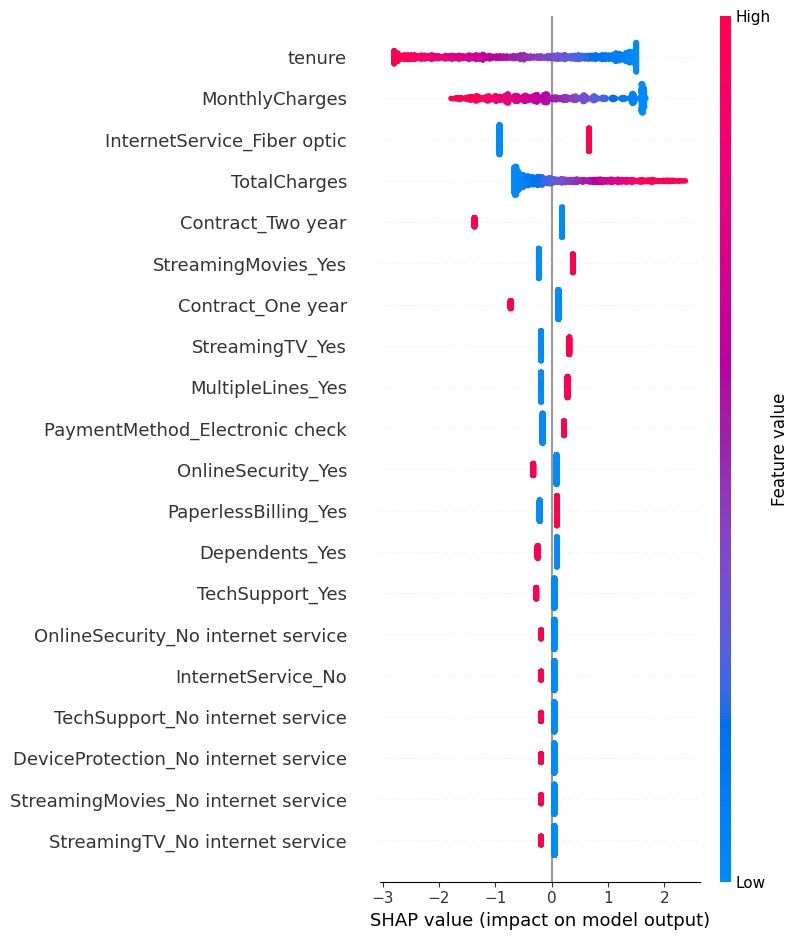

In [5]:
shap.summary_plot(shap_values, X_test)

## SHAP Summary Insights

- Customers with low tenure are more likely to churn, while long-term customers are stable.
- Higher monthly charges increase the likelihood of churn.
- Fiber optic users show higher churn risk, suggesting potential dissatisfaction or cost sensitivity.
- Customers with long-term contracts are less likely to churn due to commitment.

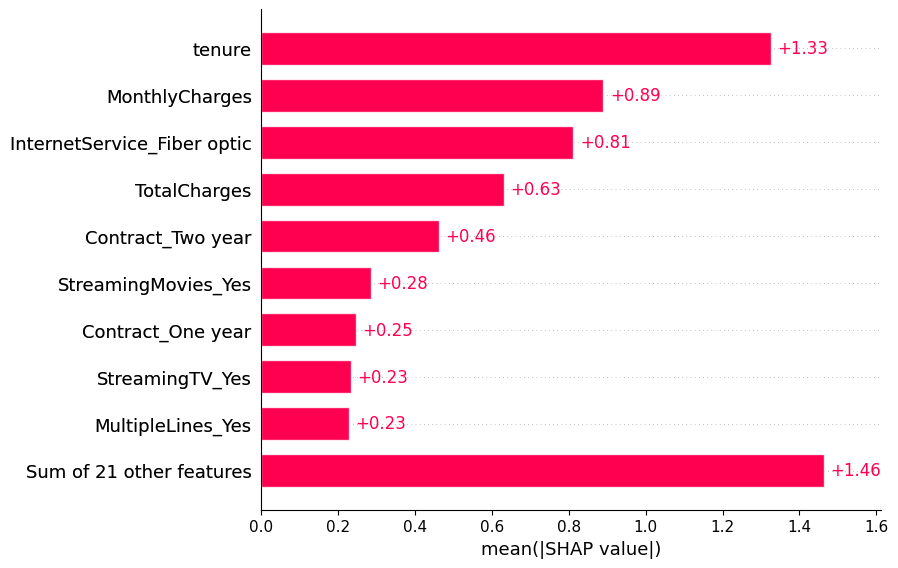

In [6]:
shap.plots.bar(shap_values)

## Global Feature Importance Insights

- Tenure is the most important factor affecting churn. Customers with shorter tenure are significantly more likely to churn.
- Monthly charges strongly influence churn, indicating that pricing plays a key role in customer retention.
- Customers using fiber optic internet show higher churn tendencies, possibly due to higher costs or service expectations.
- Contract type is critical — long-term contracts reduce churn risk.

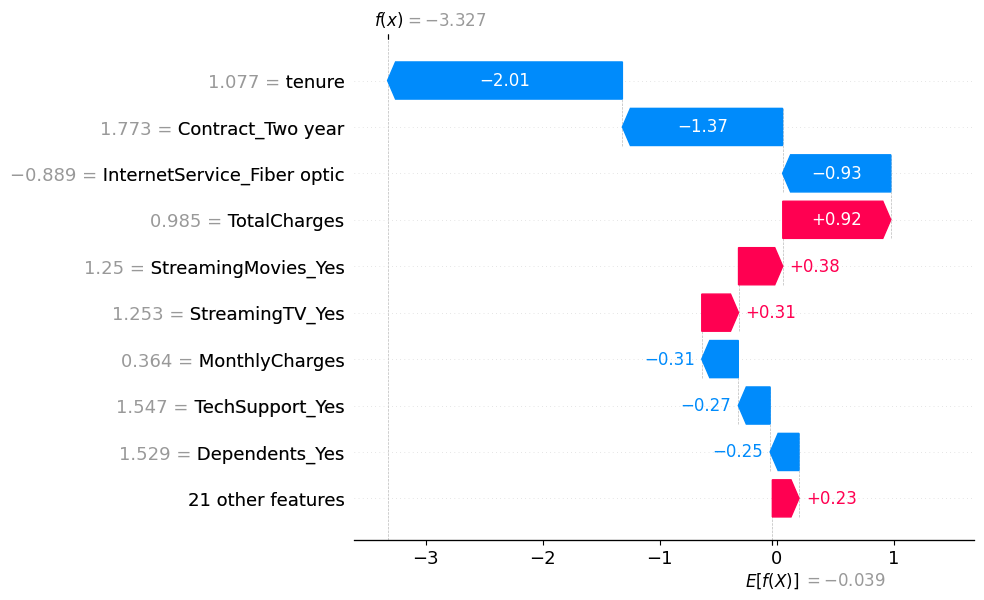

In [7]:
shap.plots.waterfall(shap_values[0])

## Individual Prediction Insight

For this customer, long tenure and a two-year contract significantly reduce churn probability.

However, higher total charges and additional services like streaming increase churn risk slightly.

Overall, the customer is unlikely to churn due to strong stabilizing factors.

## Business Insights from Explainability

- Focus on improving onboarding experience for new customers to reduce early churn
- Offer incentives for long-term contracts to improve retention
- Re-evaluate pricing strategies for high monthly charge customers
- Monitor fiber optic users closely for dissatisfaction signals
- Provide targeted offers to high-risk customers identified by the model